In [1]:
%%capture
!pip install pydub
!pip install noisereduce
!pip install pyaudio
!pip install json-tricks

In [2]:
%%capture
import os
from json_tricks import load

import numpy as np

import librosa
from pydub import AudioSegment, effects
import noisereduce as nr

import tensorflow as tf
import keras
from keras.models import model_from_json
from keras.models import load_model

import matplotlib.pyplot as plt

In [3]:
saved_model_path = './model.json'
saved_weights_path = './model_weights.h5'

#Reading the model from JSON file
with open(saved_model_path, 'r') as json_file:
    json_savedModel = json_file.read()
    
# Loading the model architecture, weights
model = tf.keras.models.model_from_json(json_savedModel)
model.load_weights(saved_weights_path)

# Compiling the model with similar parameters as the original model.
model.compile(loss='categorical_crossentropy', 
                optimizer='RMSProp', 
                metrics=['categorical_accuracy'])

print(model.summary())
total_length = 228864

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 448, 64)           20480     
                                                                 
 lstm_1 (LSTM)               (None, 64)                33024     
                                                                 
 dense (Dense)               (None, 8)                 520       
                                                                 
Total params: 54,024
Trainable params: 54,024
Non-trainable params: 0
_________________________________________________________________
None


In [4]:
def preprocess(file_path, frame_length = 2048, hop_length = 512):

    # Fetch the sample rate.
    _, sr = librosa.load(path = file_path, sr = None)
    # Load the audio file.
    rawsound = AudioSegment.from_file(file_path) 
    # Normalize the audio to +5.0 dBFS.
    normalizedsound = effects.normalize(rawsound, headroom = 0) 
    # Transform the normalized audio to np.array of samples.
    normal_x = np.array(normalizedsound.get_array_of_samples(), dtype = 'float32')

    # --- THIS IS THE CRITICAL FIX ---
    # Trim silence from the beginning and the end.
    xt, index = librosa.effects.trim(normal_x, top_db=30)
    # Pad for duration equalization (using the global 'total_length' variable)
    padded_x = np.pad(xt, (0, total_length-len(xt)), 'constant')
    # ------------------------------

    # Noise reduction (use the new 'padded_x' variable)
    final_x = nr.reduce_noise(padded_x, sr=sr)

    # Features extraction (remember to use y=)
    f1 = librosa.feature.rms(y=final_x, frame_length=frame_length, hop_length=hop_length, center=True, pad_mode='reflect').T # Energy - Root Mean Square   
    f2 = librosa.feature.zero_crossing_rate(y=final_x, frame_length=frame_length, hop_length=hop_length,center=True).T # ZCR      
    f3 = librosa.feature.mfcc(y=final_x, sr=sr, S=None, n_mfcc=13, hop_length = hop_length).T # MFCC

    # Concatenate features horizontally (axis=1)
    features = np.concatenate((f1, f2, f3), axis = 1)

    # Reshape to 3D for model input (1 sample, N timesteps, 15 features)
    features = np.reshape(features, (1, features.shape[0], features.shape[1]))

    return features

In [5]:
# Emotions list is created for a readable form of the model prediction.
import numpy as np

emotions = {
    0 : 'neutral',
    1 : 'calm',
    2 : 'happy',
    3 : 'sad',
    4 : 'angry',
    5 : 'fearful',
    6 : 'disgust',
    7 : 'suprised'   
}
emo_list = list(emotions.values())

def is_silent(data, threshold=2000000): # <-- MUCH larger threshold for 32-bit audio
    """
    Returns 'True' if the maximum absolute value of the audio data
    is below a threshold, indicating silence.
    """
    # Check if data is empty
    if len(data) == 0:
        return True
        
    # Find the maximum absolute value
    max_abs_val = np.max(np.abs(data))
    
    # Return True if below threshold
    return max_abs_val < threshold

** session started
* recording...
* done recording
1/1 [==============================] - 0s 77ms/step


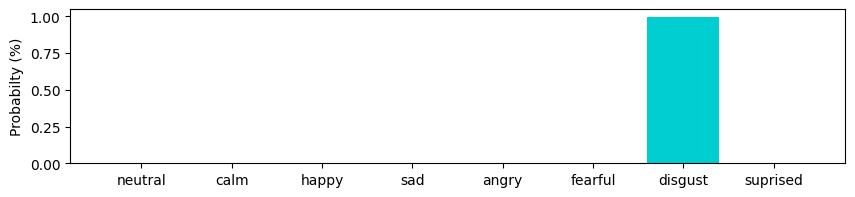

max emotion: disgust
----------------------------------------------------------------------------------------------------
* recording...
* done recording
1/1 [==============================] - 0s 53ms/step


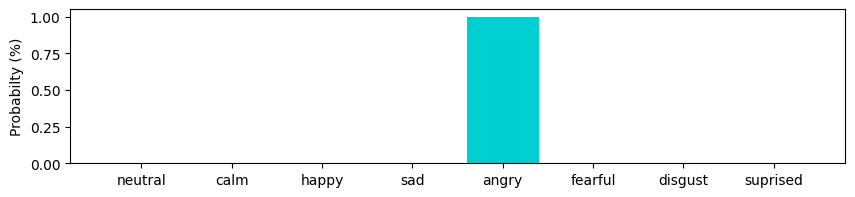

max emotion: angry
----------------------------------------------------------------------------------------------------
* recording...
* done recording
1/1 [==============================] - 0s 50ms/step


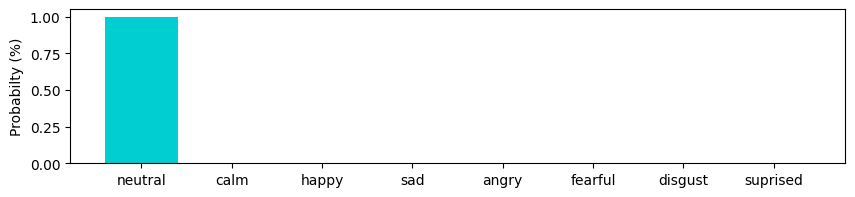

max emotion: neutral
----------------------------------------------------------------------------------------------------
* recording...
* done recording


KeyboardInterrupt: 

In [7]:
import pyaudio
import wave
from array import array
import struct
import time
import numpy as np

# Initialize variables
RATE = 24414
CHUNK = 512
RECORD_SECONDS = 7.1
SILENCE_SECONDS = 5  # <-- Changed to 5 seconds as requested

FORMAT = pyaudio.paInt32
CHANNELS = 1
WAVE_OUTPUT_FILE = "./output.wav" # Corrected path

wf = None # Fix for NameError

# Open an input channel
p = pyaudio.PyAudio()
stream = p.open(format=FORMAT,
                channels=CHANNELS,
                rate=RATE,
                input=True,
                frames_per_buffer=CHUNK)

# SESSION START
print("** session started")
total_predictions = [] 
tic = time.perf_counter()

while True: # Loop will now start correctly
    print("* recording...")
    frames = [] 
    
    timesteps = int(RATE / CHUNK * RECORD_SECONDS) # => 339

    # --- CORRECTED RECORDING LOOP ---
    # 1. Record all the frames first
    for i in range(0, timesteps):
        data = array('l', stream.read(CHUNK)) 
        frames.append(data)

    # 2. NOW, write the file ONCE
    wf = wave.open(WAVE_OUTPUT_FILE, 'wb') 
    wf.setnchannels(CHANNELS)
    wf.setsampwidth(p.get_sample_size(FORMAT))
    wf.setframerate(RATE)
    wf.writeframes(b''.join(frames))
    # --- END OF FIX ---

    print("* done recording")

    x = preprocess(WAVE_OUTPUT_FILE) 
    predictions = model.predict(x, use_multiprocessing=True)
    pred_list = list(predictions)
    pred_np = np.squeeze(np.array(pred_list).tolist(), axis=0) 
    total_predictions.append(pred_np)
    
    # Present emotion distribution
    fig = plt.figure(figsize = (10, 2))
    plt.bar(emo_list, pred_np, color = 'darkturquoise')
    plt.ylabel("Probabilty (%)")
    plt.show()
    
    max_emo = np.argmax(predictions)
    print('max emotion:', emotions.get(max_emo,-1))
    
    print(100*'-')
    
    # === CORRECTED 5-SECOND SILENCE CHECK ===
    chunks_per_second = RATE / CHUNK
    chunks_in_silence_period = int(chunks_per_second * SILENCE_SECONDS) # Use 5 seconds

    # Get the last 5 seconds of frames
    recent_frames = frames[-chunks_in_silence_period:]
    
    if len(recent_frames) > 0:
        data_to_check = np.hstack([np.array(f, dtype=np.int32) for f in recent_frames])
        if is_silent(data_to_check):
            print(f"** {SILENCE_SECONDS} seconds of silence detected. Ending session.")
            break
    # === END OF FIX ===

# SESSION END        
toc = time.perf_counter()
stream.stop_stream()
stream.close()
p.terminate()

if wf is not None: 
    wf.close()
    
print('** session ended')

# Session Summary
if len(total_predictions) > 0:
    total_predictions_np =  np.mean(np.array(total_predictions).tolist(), axis=0)
    fig = plt.figure(figsize = (10, 5))
    plt.bar(emo_list, total_predictions_np, color = 'indigo')
    plt.ylabel("Mean probabilty (%)")
    plt.title("Session Summary")
    plt.show()
else:
    print("** No audio was recorded to summarize.")

print(f"Emotions analyzed for: {(toc - tic):0.4f} seconds")